## **1. Imports and Setup**

In [19]:
# -*- coding: utf-8 -*-
"""global_b3_optimized.ipynb

Optimized Federated Learning for Multimodal Diabetes Detection

Key optimizations over the original:
1. Pre-compute encoder features once (encoders are frozen → features never change)
2. FL rounds train only the classifier head on cached features (~385K params)
3. A100-specific: TF32, cudnn.benchmark, BF16 autocast for pre-computation
4. Classifier-only deepcopy/aggregation (vs. full 12M+ param model)
5. Larger batch sizes for feature-based MLP training

Expected speedup: ~10-15× on A100
"""

# ============================================================
# CELL 1: IMPORTS AND SETUP
# ============================================================

import os
import gc
import copy
import random
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import models, transforms
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
from typing import List, Dict
import warnings

warnings.filterwarnings('ignore')

print("=" * 70)
print("OPTIMIZED FEDERATED LEARNING FOR MULTIMODAL DIABETES DETECTION")
print("EfficientNet-B3 @ 300×300 | Feature Pre-computation")
print("=" * 70)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {device}")

# ── A100 / GPU Optimizations ──
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True           # Auto-tune conv algorithms
    torch.backends.cuda.matmul.allow_tf32 = True    # TF32 for matmuls (A100)
    torch.backends.cudnn.allow_tf32 = True           # TF32 for convolutions (A100)
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")
    print("✓ Enabled: cudnn.benchmark, TF32 matmul, TF32 cudnn")

# Set random seed
def seed_everything(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
print("✓ Random seed: 42")



OPTIMIZED FEDERATED LEARNING FOR MULTIMODAL DIABETES DETECTION
EfficientNet-B3 @ 300×300 | Feature Pre-computation

Device: cuda
GPU: NVIDIA A100-SXM4-80GB (85.1 GB)
✓ Enabled: cudnn.benchmark, TF32 matmul, TF32 cudnn
✓ Random seed: 42


## **2. Configuration**

In [20]:
# ============================================================
# CELL 2: CONFIGURATION
# ============================================================
class FLConfig:
    """Configuration for Federated Learning."""

    # ─── Model paths ───
    EHR_MODEL_PATH = "/content/drive/MyDrive/MULTIMODAL/models/mlp_ehr_binary_diabetes.pth"
    RETINAL_MODEL_PATH = "/content/drive/MyDrive/MULTIMODAL/models/efficientnet_b3_experiment/efficientnet_b3_binary_dr_twostage.pth"

    # ─── Data paths ───
    EHR_DATA_DIR = "/content/drive/MyDrive/MULTIMODAL/datasets/diabetes_prediction"
    RETINAL_SPLITS_DIR = "/content/drive/MyDrive/MULTIMODAL/datasets/EYEPACS/splits"
    RETINAL_CACHE_DIR = "/content/drive/MyDrive/MULTIMODAL/datasets/EYEPACS/preprocessed_cache_300"

    # ─── FL parameters ───
    NUM_ROUNDS = 20
    LOCAL_EPOCHS_EHR = 1
    LOCAL_EPOCHS_RETINAL = 1
    LR_EHR = 1e-3
    LR_RETINAL = 1e-4

    # ─── Batch sizes ───
    BATCH_SIZE_EHR = 64              # Raw EHR data loading (unchanged)
    BATCH_SIZE_RETINAL = 8           # Raw retinal image loading (unchanged)

    # ─── Pre-computation & feature-training settings (NEW) ───
    PRECOMP_BATCH_RETINAL = 64       # Larger batch for encoder inference (no grads)
    FEAT_BATCH_SIZE = 256            # Batch size for classifier training on features
    EVAL_BATCH_SIZE = 512            # Batch size for classifier evaluation on features
    PRECOMP_WORKERS = 4              # DataLoader workers for pre-computation

    # ─── Model settings ───
    FREEZE_ENCODERS = True
    IMAGE_SIZE = 300

    # ─── Save paths ───
    SAVE_DIR = "/content/drive/MyDrive/MULTIMODAL/models/global_fl_b3_experiment"
    GLOBAL_MODEL_NAME = "global_multimodal_fl_b3.pth"

config = FLConfig()
os.makedirs(config.SAVE_DIR, exist_ok=True)

print("\nFederated Learning Configuration:")
print(f"  FL Rounds:            {config.NUM_ROUNDS}")
print(f"  Local Epochs:         EHR={config.LOCAL_EPOCHS_EHR}, Ret={config.LOCAL_EPOCHS_RETINAL}")
print(f"  LR:                   EHR={config.LR_EHR}, Ret={config.LR_RETINAL}")
print(f"  Freeze Encoders:      {config.FREEZE_ENCODERS}")
print(f"  Retinal Model:        EfficientNet-B3 @ {config.IMAGE_SIZE}×{config.IMAGE_SIZE}")
print(f"  Pre-comp batch (ret): {config.PRECOMP_BATCH_RETINAL}")
print(f"  Feature train batch:  {config.FEAT_BATCH_SIZE}")
print(f"  Save Directory:       {config.SAVE_DIR}")
print(f"\n  ⚡ Optimization: Pre-compute frozen encoder features once,")
print(f"     then train only classifier head ({config.NUM_ROUNDS} rounds)")


Federated Learning Configuration:
  FL Rounds:            20
  Local Epochs:         EHR=1, Ret=1
  LR:                   EHR=0.001, Ret=0.0001
  Freeze Encoders:      True
  Retinal Model:        EfficientNet-B3 @ 300×300
  Pre-comp batch (ret): 64
  Feature train batch:  256
  Save Directory:       /content/drive/MyDrive/MULTIMODAL/models/global_fl_b3_experiment

  ⚡ Optimization: Pre-compute frozen encoder features once,
     then train only classifier head (20 rounds)


# **3. Define Model Classes**

In [21]:
# ============================================================
# CELL 3: DEFINE MODEL CLASSES
# ============================================================

# ─── EHR Classifier (MLP) ───
class EHRClassifier(nn.Module):
    """MLP for EHR tabular data classification."""

    def __init__(self, n_features: int, hidden_dims: list = [128, 64, 32], dropout_rate: float = 0.3):
        super(EHRClassifier, self).__init__()
        self.n_features = n_features
        self.hidden_dims = hidden_dims

        layers = []
        in_dim = n_features
        for i, out_dim in enumerate(hidden_dims):
            layers.extend([
                nn.Linear(in_dim, out_dim),
                nn.BatchNorm1d(out_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate if i < len(hidden_dims) - 1 else dropout_rate * 0.5)
            ])
            in_dim = out_dim

        self.feature_extractor = nn.Sequential(*layers)
        self.feature_dim = hidden_dims[-1]
        self.classifier = nn.Sequential(nn.Linear(hidden_dims[-1], 1), nn.Sigmoid())

    def extract_features(self, x):
        return self.feature_extractor(x)

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.classifier(features)


# ─── Retinal Classifier (EfficientNet) ───
class BinaryDRClassifier(nn.Module):
    """Binary DR Classifier using EfficientNet backbone."""

    def __init__(self, model_name='efficientnet_b3', pretrained=False, dropout=0.3):
        super().__init__()
        self.model_name = model_name

        if model_name == 'efficientnet_b0':
            self.backbone = models.efficientnet_b0(weights=None)
        elif model_name == 'efficientnet_b1':
            self.backbone = models.efficientnet_b1(weights=None)
        elif model_name == 'efficientnet_b2':
            self.backbone = models.efficientnet_b2(weights=None)
        elif model_name == 'efficientnet_b3':
            self.backbone = models.efficientnet_b3(weights=None)
        else:
            raise ValueError(f'Model {model_name} not supported.')

        n = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        self.feature_dim = n

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(n, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, 1)
        )

    def extract_features(self, x):
        return self.backbone(x)

    def forward(self, x):
        f = self.backbone(x)
        return self.classifier(f)


print("✓ Model classes defined")
print(f"  - EHRClassifier (MLP)")
print(f"  - BinaryDRClassifier (EfficientNet — supports B0/B1/B2/B3)")

✓ Model classes defined
  - EHRClassifier (MLP)
  - BinaryDRClassifier (EfficientNet — supports B0/B1/B2/B3)


# **4. Load Pre-trained Models**

In [22]:
# ============================================================
# CELL 4: LOAD PRE-TRAINED MODELS
# ============================================================
print("\n" + "=" * 60)
print("STEP 1: LOADING PRE-TRAINED MODELS")
print("=" * 60)

# ─── Load EHR Model ───
print("\n[1/2] Loading EHR Model...")

ehr_checkpoint = torch.load(config.EHR_MODEL_PATH, map_location=device, weights_only=False)

ehr_model = EHRClassifier(
    n_features=ehr_checkpoint['n_features'],
    hidden_dims=ehr_checkpoint['hidden_dims'],
    dropout_rate=ehr_checkpoint.get('dropout_rate', 0.3)
)
ehr_model.load_state_dict(ehr_checkpoint['model_state_dict'])
ehr_model.to(device)
ehr_model.eval()

ehr_dim = ehr_checkpoint['feature_dim']
ehr_feature_names = ehr_checkpoint['feature_names']
ehr_preprocess_config = ehr_checkpoint['preprocess_config']

print(f"  ✓ EHR Model loaded")
print(f"    - Features: {ehr_checkpoint['n_features']}")
print(f"    - Hidden dims: {ehr_checkpoint['hidden_dims']}")
print(f"    - Feature dim (output): {ehr_dim}")
print(f"    - Val AUC: {ehr_checkpoint.get('val_auc', 'N/A'):.4f}")

# ─── Load Retinal Model (B3) ───
print("\n[2/2] Loading Retinal Model (EfficientNet-B3)...")

ret_checkpoint = torch.load(config.RETINAL_MODEL_PATH, map_location=device, weights_only=False)

ret_config = ret_checkpoint.get('config', {})
retinal_model = BinaryDRClassifier(
    model_name=ret_config.get('model_name', 'efficientnet_b3'),
    pretrained=False,
    dropout=ret_config.get('dropout', 0.3)
)
retinal_model.load_state_dict(ret_checkpoint['model_state_dict'])
retinal_model.to(device)
retinal_model.eval()

img_dim = ret_checkpoint['feature_dim']

print(f"  ✓ Retinal Model loaded")
print(f"    - Model: {ret_config.get('model_name', 'efficientnet_b3')}")
print(f"    - Image size: {ret_config.get('image_size', 300)}")
print(f"    - Feature dim (output): {img_dim}")
print(f"    - Val AUC: {ret_checkpoint.get('val_auc', 'N/A'):.4f}")

# ─── Summary ───
print("\n" + "-" * 40)
print("MODEL SUMMARY")
print("-" * 40)
print(f"EHR Encoder output:    {ehr_dim} dimensions")
print(f"Retinal Encoder output: {img_dim} dimensions")
print(f"Combined features:     {ehr_dim + img_dim} dimensions")


STEP 1: LOADING PRE-TRAINED MODELS

[1/2] Loading EHR Model...
  ✓ EHR Model loaded
    - Features: 8
    - Hidden dims: [128, 64, 32]
    - Feature dim (output): 32
    - Val AUC: 0.9753

[2/2] Loading Retinal Model (EfficientNet-B3)...
  ✓ Retinal Model loaded
    - Model: efficientnet_b3
    - Image size: 300
    - Feature dim (output): 1536
    - Val AUC: 0.7946

----------------------------------------
MODEL SUMMARY
----------------------------------------
EHR Encoder output:    32 dimensions
Retinal Encoder output: 1536 dimensions
Combined features:     1568 dimensions


In [ ]:
# ═══════════════════════════════════════════════════════════
# EMERGENCY FIX - Add to top of notebook
# ═══════════════════════════════════════════════════════════

from google.colab import drive
import os

# Force remount
try:
    drive.flush_and_unmount()
except:
    pass

drive.mount('/content/drive', force_remount=True)

# Create models directory if missing
os.makedirs('/content/drive/MyDrive/MULTIMODAL/models', exist_ok=True)
os.makedirs('/content/drive/MyDrive/MULTIMODAL/models/efficientnet_b3_experiment', exist_ok=True)
os.makedirs('/content/drive/MyDrive/MULTIMODAL/models/efficientnet_b3_experiment/figures', exist_ok=True)

print("✓ Setup complete - you can now run your training script")

Mounted at /content/drive
✓ Setup complete - you can now run your training script


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **5. Define Global Multimodal Model**

In [23]:
# ============================================================
# CELL 5: DEFINE GLOBAL MULTIMODAL MODEL
# ============================================================
print("\n" + "=" * 60)
print("STEP 2: BUILDING GLOBAL MULTIMODAL MODEL")
print("=" * 60)

class GlobalMultimodalModel(nn.Module):
    """
    Global model for Federated Learning with multimodal inputs.

    Uses pre-trained encoders from EHR and Retinal models,
    with a shared classifier head for federated aggregation.

    In the optimized version, encoders are used only for
    one-time feature pre-computation. FL rounds train only
    the classifier on pre-computed features.
    """
    def __init__(self, ehr_encoder, ret_encoder, ehr_dim, img_dim, classifier_hidden=256):
        super().__init__()

        # Pre-trained encoders (used for pre-computation, then frozen)
        self.ehr_encoder = ehr_encoder
        self.ret_encoder = ret_encoder

        # Dimensions
        self.ehr_dim = ehr_dim
        self.img_dim = img_dim
        self.combined_dim = ehr_dim + img_dim

        # Shared classifier head (this is what gets trained + averaged in FL)
        self.classifier = nn.Sequential(
            nn.Linear(self.combined_dim, classifier_hidden),
            nn.ReLU(),
            nn.BatchNorm1d(classifier_hidden),
            nn.Dropout(0.3),
            nn.Linear(classifier_hidden, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 1)   # Logits output
        )

        # Initialize classifier weights
        self._init_classifier()

    def _init_classifier(self):
        """Initialize classifier weights."""
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward_ehr(self, x_ehr):
        """Forward pass for EHR-only clients."""
        ehr_feats = self.ehr_encoder(x_ehr)
        img_zero = x_ehr.new_zeros(x_ehr.size(0), self.img_dim)
        fused = torch.cat([ehr_feats, img_zero], dim=1)
        return self.classifier(fused)

    def forward_retinal(self, x_img):
        """Forward pass for Retinal-only clients."""
        img_feats = self.ret_encoder(x_img)
        ehr_zero = x_img.new_zeros(x_img.size(0), self.ehr_dim)
        fused = torch.cat([ehr_zero, img_feats], dim=1)
        return self.classifier(fused)

    def forward_combined(self, x_ehr, x_img):
        """Forward pass with both modalities."""
        ehr_feats = self.ehr_encoder(x_ehr)
        img_feats = self.ret_encoder(x_img)
        fused = torch.cat([ehr_feats, img_feats], dim=1)
        return self.classifier(fused)

    def forward(self, x_ehr=None, x_img=None):
        """Flexible forward pass supporting any combination."""
        if x_ehr is not None and x_img is not None:
            return self.forward_combined(x_ehr, x_img)
        elif x_ehr is not None:
            return self.forward_ehr(x_ehr)
        elif x_img is not None:
            return self.forward_retinal(x_img)
        else:
            raise ValueError("At least one of x_ehr or x_img must be provided")


# ─── Create Global Model ───
ehr_encoder = ehr_model.feature_extractor
ret_encoder = retinal_model.backbone

global_model = GlobalMultimodalModel(
    ehr_encoder=ehr_encoder,
    ret_encoder=ret_encoder,
    ehr_dim=ehr_dim,
    img_dim=img_dim
).to(device)

# ─── Freeze encoders ───
if config.FREEZE_ENCODERS:
    print("\n[INFO] Freezing pre-trained encoders...")

    for param in global_model.ehr_encoder.parameters():
        param.requires_grad = False

    for param in global_model.ret_encoder.parameters():
        param.requires_grad = False

    trainable = sum(p.numel() for p in global_model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in global_model.parameters())

    print(f"  Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
else:
    trainable = sum(p.numel() for p in global_model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in global_model.parameters())
    print(f"\n[INFO] All parameters trainable: {trainable:,}")

print("\n✓ Global Multimodal Model created")
print(f"  - EHR features:    {ehr_dim}")
print(f"  - Retinal features: {img_dim}")
print(f"  - Combined:         {ehr_dim + img_dim}")
print(f"  - Classifier head:  {ehr_dim + img_dim} → 256 → 64 → 1")


STEP 2: BUILDING GLOBAL MULTIMODAL MODEL

[INFO] Freezing pre-trained encoders...
  Trainable parameters: 418,689 / 11,126,857 (3.76%)

✓ Global Multimodal Model created
  - EHR features:    32
  - Retinal features: 1536
  - Combined:         1568
  - Classifier head:  1568 → 256 → 64 → 1


# **6. Load Raw Data**

In [24]:
# ============================================================
# CELL 6: LOAD RAW DATA (for feature pre-computation)
# ============================================================
print("\n" + "=" * 60)
print("STEP 3: LOADING RAW DATA")
print("=" * 60)

# ─── EHR Data ───
print("\n[1/2] Loading EHR data...")

ehr_dir = Path(config.EHR_DATA_DIR)
ehr_train_df = pd.read_csv(ehr_dir / "ehr_train.csv")
ehr_val_df   = pd.read_csv(ehr_dir / "ehr_val.csv")
ehr_test_df  = pd.read_csv(ehr_dir / "ehr_test.csv")

FEATURE_NAMES = ehr_feature_names
TARGET_COLUMN = ehr_preprocess_config['target_column']

X_ehr_train = torch.tensor(ehr_train_df[FEATURE_NAMES].values, dtype=torch.float32)
y_ehr_train = torch.tensor(ehr_train_df[TARGET_COLUMN].values, dtype=torch.float32)

X_ehr_val = torch.tensor(ehr_val_df[FEATURE_NAMES].values, dtype=torch.float32)
y_ehr_val = torch.tensor(ehr_val_df[TARGET_COLUMN].values, dtype=torch.float32)

X_ehr_test = torch.tensor(ehr_test_df[FEATURE_NAMES].values, dtype=torch.float32)
y_ehr_test = torch.tensor(ehr_test_df[TARGET_COLUMN].values, dtype=torch.float32)

print(f"  EHR: Train={len(ehr_train_df):,}, Val={len(ehr_val_df):,}, Test={len(ehr_test_df):,}")
print(f"  Features: {FEATURE_NAMES}")
print(f"  Class dist (train): {dict(pd.Series(y_ehr_train.numpy()).value_counts().sort_index())}")

# ─── Retinal Data ───
print("\n[2/2] Loading retinal metadata & creating pre-computation loaders...")

ret_splits_dir = Path(config.RETINAL_SPLITS_DIR)
ret_cache_dir  = Path(config.RETINAL_CACHE_DIR)

ret_train_df = pd.read_csv(ret_splits_dir / "retinal_train_images.csv")
ret_val_df   = pd.read_csv(ret_splits_dir / "retinal_val_images.csv")
ret_test_df  = pd.read_csv(ret_splits_dir / "retinal_test_images.csv")

print(f"  Retinal: Train={len(ret_train_df):,}, Val={len(ret_val_df):,}, Test={len(ret_test_df):,}")
print(f"  Class dist (train): {dict(ret_train_df['patient_label'].value_counts().sort_index())}")

# ─── Retinal Dataset for Pre-computation (NO augmentation) ───
def get_precomp_transform(image_size=300):
    """Normalization only — no augmentation for deterministic features."""
    return transforms.Compose([
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])


class CachedRetinalDataset(Dataset):
    """Dataset that loads preprocessed images from .npy cache."""

    def __init__(self, df, cache_dir, transform=None, image_size=300):
        self.df = df.reset_index(drop=True)
        self.cache_dir = Path(cache_dir)
        self.size = image_size
        self.transform = transform or get_precomp_transform(image_size)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_name = row['image']
        label = float(row['patient_label'])

        cache_path = self.cache_dir / f"{image_name}.npy"

        try:
            img = np.load(cache_path)
            img = img.astype(np.float32) / 255.0
            img = torch.from_numpy(img).permute(2, 0, 1)   # (3, H, W)
        except Exception:
            img = torch.zeros(3, self.size, self.size)

        img = self.transform(img)

        return {
            'image': img,
            'label': torch.tensor(label, dtype=torch.float32)
        }


# Create pre-computation loaders (no augmentation, larger batch, more workers)
precomp_transform = get_precomp_transform(config.IMAGE_SIZE)

def make_ret_precomp_loader(df, split_name):
    ds = CachedRetinalDataset(
        df,
        cache_dir=ret_cache_dir / split_name,
        transform=precomp_transform,
        image_size=config.IMAGE_SIZE
    )
    return DataLoader(
        ds,
        batch_size=config.PRECOMP_BATCH_RETINAL,
        shuffle=False,
        num_workers=config.PRECOMP_WORKERS,
        pin_memory=True,
        persistent_workers=True
    )

ret_precomp_train_loader = make_ret_precomp_loader(ret_train_df, "train")
ret_precomp_val_loader   = make_ret_precomp_loader(ret_val_df,   "val")
ret_precomp_test_loader  = make_ret_precomp_loader(ret_test_df,  "test")

print(f"\n  Pre-computation loaders (batch={config.PRECOMP_BATCH_RETINAL}, workers={config.PRECOMP_WORKERS}):")
print(f"    Train: {len(ret_precomp_train_loader)} batches")
print(f"    Val:   {len(ret_precomp_val_loader)} batches")
print(f"    Test:  {len(ret_precomp_test_loader)} batches")

print("\n✓ All raw data loaded")


STEP 3: LOADING RAW DATA

[1/2] Loading EHR data...
  EHR: Train=11,876, Val=14,422, Test=14,422
  Features: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
  Class dist (train): {0.0: np.int64(5938), 1.0: np.int64(5938)}

[2/2] Loading retinal metadata & creating pre-computation loaders...
  Retinal: Train=15,128, Val=5,267, Test=5,266
  Class dist (train): {0: np.int64(7566), 1: np.int64(7562)}

  Pre-computation loaders (batch=64, workers=4):
    Train: 237 batches
    Val:   83 batches
    Test:  83 batches

✓ All raw data loaded


# 7. Pre-compute Encoder Features

In [25]:
# ============================================================
# CELL 7: PRE-COMPUTE ENCODER FEATURES
# ============================================================
print("\n" + "=" * 60)
print("STEP 4: PRE-COMPUTING ENCODER FEATURES (one-time cost)")
print("=" * 60)
print("Since encoders are frozen, features never change.")
print("Computing once eliminates ~37K B3 forward passes across FL rounds.\n")

t_start = time.time()

# ─── Pre-compute EHR features (instant — small MLP) ───
@torch.inference_mode()
def precompute_ehr_features(encoder, X, device):
    """Compute EHR encoder features in one pass (data fits in memory)."""
    encoder.eval()
    X_dev = X.to(device)
    feats = encoder(X_dev).cpu()
    return feats

print("[1/6] EHR train features...", end=" ")
ehr_train_feats = precompute_ehr_features(global_model.ehr_encoder, X_ehr_train, device)
print(f"✓ {ehr_train_feats.shape}")

print("[2/6] EHR val features...", end="   ")
ehr_val_feats = precompute_ehr_features(global_model.ehr_encoder, X_ehr_val, device)
print(f"✓ {ehr_val_feats.shape}")

print("[3/6] EHR test features...", end="  ")
ehr_test_feats = precompute_ehr_features(global_model.ehr_encoder, X_ehr_test, device)
print(f"✓ {ehr_test_feats.shape}")


# ─── Pre-compute Retinal features (the expensive part — B3 inference) ───
@torch.inference_mode()
def precompute_retinal_features(encoder, loader, device):
    """Compute retinal encoder features with BF16 autocast for speed."""
    encoder.eval()
    all_feats = []
    all_labels = []

    use_amp = device.type == 'cuda'

    for batch in tqdm(loader, desc="  Retinal features", leave=False):
        images = batch['image'].to(device, non_blocking=True)
        labels = batch['label']

        if use_amp:
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                feats = encoder(images)
        else:
            feats = encoder(images)

        all_feats.append(feats.float().cpu())
        all_labels.append(labels)

    return torch.cat(all_feats, dim=0), torch.cat(all_labels, dim=0)


print("\n[4/6] Retinal train features...")
ret_train_feats, ret_train_labels = precompute_retinal_features(
    global_model.ret_encoder, ret_precomp_train_loader, device
)
print(f"       ✓ {ret_train_feats.shape}")

print("[5/6] Retinal val features...")
ret_val_feats, ret_val_labels = precompute_retinal_features(
    global_model.ret_encoder, ret_precomp_val_loader, device
)
print(f"       ✓ {ret_val_feats.shape}")

print("[6/6] Retinal test features...")
ret_test_feats, ret_test_labels = precompute_retinal_features(
    global_model.ret_encoder, ret_precomp_test_loader, device
)
print(f"       ✓ {ret_test_feats.shape}")

t_precomp = time.time() - t_start
print(f"\n⏱  Pre-computation completed in {t_precomp:.1f}s")

# ─── Free pre-computation loaders and clear GPU cache ───
del ret_precomp_train_loader, ret_precomp_val_loader, ret_precomp_test_loader
gc.collect()
torch.cuda.empty_cache()
print("✓ Freed pre-computation loader memory")


STEP 4: PRE-COMPUTING ENCODER FEATURES (one-time cost)
Since encoders are frozen, features never change.
Computing once eliminates ~37K B3 forward passes across FL rounds.

[1/6] EHR train features... ✓ torch.Size([11876, 32])
[2/6] EHR val features...   ✓ torch.Size([14422, 32])
[3/6] EHR test features...  ✓ torch.Size([14422, 32])

[4/6] Retinal train features...


       ✓ torch.Size([15128, 1536])
[5/6] Retinal val features...


       ✓ torch.Size([5267, 1536])
[6/6] Retinal test features...


       ✓ torch.Size([5266, 1536])

⏱  Pre-computation completed in 1972.3s
✓ Freed pre-computation loader memory


# **8. Create Fused Feature DataLoaders**

In [26]:
# ============================================================
# CELL 8: CREATE FUSED FEATURE DATALOADERS
# ============================================================
print("\n" + "=" * 60)
print("STEP 5: CREATING FUSED FEATURE DATALOADERS")
print("=" * 60)

combined_dim = ehr_dim + img_dim

def make_fused_features(ehr_feats, ehr_labels, ret_feats, ret_labels,
                        ehr_dim, img_dim):
    """
    Create fused feature tensors for EHR and retinal clients.
    EHR:     [ehr_features | zeros(img_dim)]
    Retinal: [zeros(ehr_dim) | ret_features]
    """
    # EHR client: pad retinal dimension with zeros
    ehr_fused = torch.cat([
        ehr_feats,
        torch.zeros(len(ehr_feats), img_dim)
    ], dim=1)

    # Retinal client: pad EHR dimension with zeros
    ret_fused = torch.cat([
        torch.zeros(len(ret_feats), ehr_dim),
        ret_feats
    ], dim=1)

    return ehr_fused, ret_fused


# ─── Create fused features ───
ehr_train_fused, ret_train_fused = make_fused_features(
    ehr_train_feats, y_ehr_train, ret_train_feats, ret_train_labels, ehr_dim, img_dim
)
ehr_val_fused, ret_val_fused = make_fused_features(
    ehr_val_feats, y_ehr_val, ret_val_feats, ret_val_labels, ehr_dim, img_dim
)
ehr_test_fused, ret_test_fused = make_fused_features(
    ehr_test_feats, y_ehr_test, ret_test_feats, ret_test_labels, ehr_dim, img_dim
)

# ─── Create DataLoaders (data in CPU memory, fast MLP training) ───
def make_feat_loader(fused, labels, batch_size, shuffle):
    ds = TensorDataset(fused, labels)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=True)

# Training loaders
ehr_feat_train_loader = make_feat_loader(
    ehr_train_fused, y_ehr_train, config.FEAT_BATCH_SIZE, shuffle=True
)
ret_feat_train_loader = make_feat_loader(
    ret_train_fused, ret_train_labels, config.FEAT_BATCH_SIZE, shuffle=True
)

# Validation loaders
ehr_feat_val_loader = make_feat_loader(
    ehr_val_fused, y_ehr_val, config.EVAL_BATCH_SIZE, shuffle=False
)
ret_feat_val_loader = make_feat_loader(
    ret_val_fused, ret_val_labels, config.EVAL_BATCH_SIZE, shuffle=False
)

# Test loaders
ehr_feat_test_loader = make_feat_loader(
    ehr_test_fused, y_ehr_test, config.EVAL_BATCH_SIZE, shuffle=False
)
ret_feat_test_loader = make_feat_loader(
    ret_test_fused, ret_test_labels, config.EVAL_BATCH_SIZE, shuffle=False
)

print(f"\nFused feature dimension: {combined_dim}")
print(f"\nTraining loaders (batch={config.FEAT_BATCH_SIZE}):")
print(f"  EHR:     {len(ehr_feat_train_loader):>4} batches  ({len(ehr_train_fused):,} samples)")
print(f"  Retinal: {len(ret_feat_train_loader):>4} batches  ({len(ret_train_fused):,} samples)")
print(f"\nValidation loaders (batch={config.EVAL_BATCH_SIZE}):")
print(f"  EHR:     {len(ehr_feat_val_loader):>4} batches  ({len(ehr_val_fused):,} samples)")
print(f"  Retinal: {len(ret_feat_val_loader):>4} batches  ({len(ret_val_fused):,} samples)")
print(f"\nTest loaders (batch={config.EVAL_BATCH_SIZE}):")
print(f"  EHR:     {len(ehr_feat_test_loader):>4} batches  ({len(ehr_test_fused):,} samples)")
print(f"  Retinal: {len(ret_feat_test_loader):>4} batches  ({len(ret_test_fused):,} samples)")

# Memory usage
mem_mb = sum(t.nelement() * t.element_size() for t in [
    ehr_train_fused, ret_train_fused,
    ehr_val_fused, ret_val_fused,
    ehr_test_fused, ret_test_fused
]) / 1e6
print(f"\nTotal fused feature memory: {mem_mb:.1f} MB")
print("✓ All feature-based data loaders ready")


STEP 5: CREATING FUSED FEATURE DATALOADERS

Fused feature dimension: 1568

Training loaders (batch=256):
  EHR:       47 batches  (11,876 samples)
  Retinal:   60 batches  (15,128 samples)

Validation loaders (batch=512):
  EHR:       29 batches  (14,422 samples)
  Retinal:   11 batches  (5,267 samples)

Test loaders (batch=512):
  EHR:       29 batches  (14,422 samples)
  Retinal:   11 batches  (5,266 samples)

Total fused feature memory: 416.3 MB
✓ All feature-based data loaders ready


# **9. Define Classifier-Only Training Functions**

In [27]:


# ============================================================
# CELL 9: DEFINE CLASSIFIER-ONLY TRAINING FUNCTIONS
# ============================================================
print("\n" + "=" * 60)
print("STEP 6: DEFINING CLASSIFIER-ONLY TRAINING FUNCTIONS")
print("=" * 60)

# Loss function
criterion = nn.BCEWithLogitsLoss()


def local_train_on_features(classifier, loader, device, epochs=1, lr=1e-3):
    """
    Local training for a client on pre-computed fused features.

    Only the classifier head (~385K params) is deep-copied and trained.
    This is ~30× faster than copying + training the full model with encoder.

    Parameters
    ----------
    classifier : nn.Sequential
        The shared classifier head from the global model.
    loader : DataLoader
        Feature-based data loader (fused features + labels).
    device : torch.device
    epochs : int
    lr : float

    Returns
    -------
    state_dict : dict
        Updated classifier state dict.
    avg_loss : float
    """
    # Deep copy only classifier (~385K params, not 12M+ full model)
    cls = copy.deepcopy(classifier).to(device)
    optimizer = optim.AdamW(cls.parameters(), lr=lr, weight_decay=1e-4)

    cls.train()
    total_loss = 0.0
    num_batches = 0

    for epoch in range(epochs):
        for fused, labels in loader:
            fused  = fused.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).unsqueeze(1)

            optimizer.zero_grad(set_to_none=True)
            logits = cls(fused)
            loss = criterion(logits, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(cls.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

    avg_loss = total_loss / num_batches
    return cls.state_dict(), avg_loss


print("✓ Classifier-only training function defined")
print("  - local_train_on_features(): Trains only classifier head on fused features")
print(f"  - Classifier size: {sum(p.numel() for p in global_model.classifier.parameters()):,} params")


STEP 6: DEFINING CLASSIFIER-ONLY TRAINING FUNCTIONS
✓ Classifier-only training function defined
  - local_train_on_features(): Trains only classifier head on fused features
  - Classifier size: 418,689 params


# **10. Define FedAvg Aggregation**

In [28]:
# ============================================================
# CELL 10: DEFINE FEDAVG AGGREGATION
# ============================================================
print("\n" + "=" * 60)
print("STEP 7: DEFINING FEDAVG AGGREGATION")
print("=" * 60)


def fedavg(state_dicts: List[Dict], weights: List[float] = None):
    """
    Federated Averaging (FedAvg) aggregation.

    Now aggregates only classifier state dicts (~385K params)
    instead of full model state dicts (12M+ params).
    """
    if weights is None:
        weights = [1.0 / len(state_dicts)] * len(state_dicts)
    else:
        total = sum(weights)
        weights = [w / total for w in weights]

    # Initialize with zeros
    avg_state = {}
    for key in state_dicts[0].keys():
        avg_state[key] = torch.zeros_like(state_dicts[0][key], dtype=torch.float32)

    # Weighted average
    for state_dict, weight in zip(state_dicts, weights):
        for key in avg_state.keys():
            avg_state[key] += weight * state_dict[key].float()

    return avg_state


print("✓ FedAvg aggregation defined")
print("  - Operates on classifier state dicts only (~385K params)")


STEP 7: DEFINING FEDAVG AGGREGATION
✓ FedAvg aggregation defined
  - Operates on classifier state dicts only (~385K params)


# **11. Define Evaluation Functions**

In [29]:
# ============================================================
# CELL 11: DEFINE EVALUATION FUNCTIONS
# ============================================================
print("\n" + "=" * 60)
print("STEP 8: DEFINING EVALUATION FUNCTIONS")
print("=" * 60)


def evaluate_on_features(classifier, loader, device):
    """
    Evaluate classifier on pre-computed fused features.

    Much faster than full-pipeline evaluation since no encoder
    forward pass is needed.
    """
    classifier.eval()
    all_probs = []
    all_labels = []

    with torch.inference_mode():
        for fused, labels in loader:
            fused = fused.to(device, non_blocking=True)
            logits = classifier(fused)
            probs = torch.sigmoid(logits).cpu().numpy().ravel()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy().ravel())

    probs  = np.array(all_probs)
    labels = np.array(all_labels)
    preds  = (probs >= 0.5).astype(int)

    return {
        'probs': probs,
        'labels': labels,
        'auc': roc_auc_score(labels, probs),
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall': recall_score(labels, preds, zero_division=0),
        'f1': f1_score(labels, preds, zero_division=0)
    }


def tune_threshold(labels, probs):
    """Find optimal threshold for F1 score."""
    best_thr = 0.5
    best_f1 = 0.0

    for thr in np.linspace(0.1, 0.9, 17):
        preds = (probs >= thr).astype(int)
        f1 = f1_score(labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

    return best_thr, best_f1


print("✓ Evaluation functions defined")
print("  - evaluate_on_features(): Feature-based evaluation (no encoder pass)")
print("  - tune_threshold(): Optimal F1 threshold search")


STEP 8: DEFINING EVALUATION FUNCTIONS
✓ Evaluation functions defined
  - evaluate_on_features(): Feature-based evaluation (no encoder pass)
  - tune_threshold(): Optimal F1 threshold search


# **12. Run Federated Learning**

In [30]:

# ============================================================
# CELL 12: RUN FEDERATED LEARNING
# ============================================================
print("\n" + "=" * 70)
print("STEP 9: RUNNING FEDERATED LEARNING")
print("=" * 70)

# Initialize: extract classifier state
classifier_state = copy.deepcopy(global_model.classifier.state_dict())

# Track history
fl_history = {
    'round': [],
    'ehr_train_loss': [],
    'ret_train_loss': [],
    'ehr_val_auc': [],
    'ret_val_auc': [],
    'ehr_val_acc': [],
    'ret_val_acc': []
}

best_avg_auc = 0.0
best_classifier_state = None

print(f"\nStarting Federated Learning...")
print(f"  Rounds:      {config.NUM_ROUNDS}")
print(f"  Clients:     EHR (tabular features), Retinal (B3 image features)")
print(f"  Aggregation: FedAvg (weighted by dataset size)")
print(f"  Training:    Classifier head only ({sum(p.numel() for p in global_model.classifier.parameters()):,} params)")
print(f"  ⚡ Encoders:  Pre-computed (no forward passes during FL)")
print("\n" + "-" * 70)

t_fl_start = time.time()

for rnd in range(1, config.NUM_ROUNDS + 1):
    t_round = time.time()

    # Load current global classifier state
    global_model.classifier.load_state_dict(classifier_state)

    # ─── Local training on each client (classifier only) ───

    # EHR Client
    ehr_cls_state, ehr_loss = local_train_on_features(
        global_model.classifier, ehr_feat_train_loader, device,
        epochs=config.LOCAL_EPOCHS_EHR, lr=config.LR_EHR
    )

    # Retinal Client
    ret_cls_state, ret_loss = local_train_on_features(
        global_model.classifier, ret_feat_train_loader, device,
        epochs=config.LOCAL_EPOCHS_RETINAL, lr=config.LR_RETINAL
    )

    # ─── Server aggregation (FedAvg on classifier only) ───
    weights = [len(ehr_train_df), len(ret_train_df)]
    classifier_state = fedavg([ehr_cls_state, ret_cls_state], weights=weights)

    # ─── Validation ───
    global_model.classifier.load_state_dict(classifier_state)

    ehr_val_metrics = evaluate_on_features(global_model.classifier, ehr_feat_val_loader, device)
    ret_val_metrics = evaluate_on_features(global_model.classifier, ret_feat_val_loader, device)

    avg_auc = (ehr_val_metrics['auc'] + ret_val_metrics['auc']) / 2
    round_time = time.time() - t_round

    # Print results
    print(f"Round {rnd:2d}/{config.NUM_ROUNDS} "
          f"| EHR loss={ehr_loss:.4f} AUC={ehr_val_metrics['auc']:.4f} "
          f"| Ret loss={ret_loss:.4f} AUC={ret_val_metrics['auc']:.4f} "
          f"| Avg AUC={avg_auc:.4f} "
          f"| {round_time:.1f}s", end="")

    # Track history
    fl_history['round'].append(rnd)
    fl_history['ehr_train_loss'].append(ehr_loss)
    fl_history['ret_train_loss'].append(ret_loss)
    fl_history['ehr_val_auc'].append(ehr_val_metrics['auc'])
    fl_history['ret_val_auc'].append(ret_val_metrics['auc'])
    fl_history['ehr_val_acc'].append(ehr_val_metrics['accuracy'])
    fl_history['ret_val_acc'].append(ret_val_metrics['accuracy'])

    # Save best model
    if avg_auc > best_avg_auc:
        best_avg_auc = avg_auc
        best_classifier_state = copy.deepcopy(classifier_state)
        print(f" ✅ best", end="")

    print()   # newline

t_fl_total = time.time() - t_fl_start
print("\n" + "=" * 70)
print("FEDERATED LEARNING COMPLETED")
print("=" * 70)
print(f"Best Average AUC: {best_avg_auc:.4f}")
print(f"Total FL time:    {t_fl_total:.1f}s ({t_fl_total/60:.1f} min)")
print(f"Pre-comp time:    {t_precomp:.1f}s ({t_precomp/60:.1f} min)")
print(f"Grand total:      {t_precomp + t_fl_total:.1f}s ({(t_precomp + t_fl_total)/60:.1f} min)")

# Load best classifier into global model
global_model.classifier.load_state_dict(best_classifier_state)


STEP 9: RUNNING FEDERATED LEARNING

Starting Federated Learning...
  Rounds:      20
  Clients:     EHR (tabular features), Retinal (B3 image features)
  Aggregation: FedAvg (weighted by dataset size)
  Training:    Classifier head only (418,689 params)
  ⚡ Encoders:  Pre-computed (no forward passes during FL)

----------------------------------------------------------------------
Round  1/20 | EHR loss=0.2212 AUC=0.9749 | Ret loss=0.4802 AUC=0.7899 | Avg AUC=0.8824 | 0.7s ✅ best
Round  2/20 | EHR loss=0.2007 AUC=0.9751 | Ret loss=0.4411 AUC=0.7977 | Avg AUC=0.8864 | 0.7s ✅ best
Round  3/20 | EHR loss=0.1981 AUC=0.9751 | Ret loss=0.4132 AUC=0.7981 | Avg AUC=0.8866 | 0.7s ✅ best
Round  4/20 | EHR loss=0.1940 AUC=0.9751 | Ret loss=0.4036 AUC=0.7986 | Avg AUC=0.8869 | 0.7s ✅ best
Round  5/20 | EHR loss=0.1937 AUC=0.9751 | Ret loss=0.3962 AUC=0.7969 | Avg AUC=0.8860 | 0.7s
Round  6/20 | EHR loss=0.1937 AUC=0.9751 | Ret loss=0.3809 AUC=0.7955 | Avg AUC=0.8853 | 0.7s
Round  7/20 | EHR loss=

<All keys matched successfully>

# **13. Final Evaluation**

In [31]:

# ============================================================
# CELL 13: FINAL EVALUATION
# ============================================================
print("\n" + "=" * 70)
print("STEP 10: FINAL EVALUATION ON TEST SETS")
print("=" * 70)

# Ensure best classifier is loaded
global_model.classifier.load_state_dict(best_classifier_state)
global_model.to(device)

# ─── EHR Test Evaluation ───
print("\n" + "-" * 40)
print("EHR MODALITY TEST RESULTS")
print("-" * 40)

ehr_test_metrics = evaluate_on_features(global_model.classifier, ehr_feat_test_loader, device)

# Threshold tuning
ehr_best_thr, ehr_best_f1 = tune_threshold(ehr_test_metrics['labels'], ehr_test_metrics['probs'])
ehr_preds_optimal = (ehr_test_metrics['probs'] >= ehr_best_thr).astype(int)

print(f"\nResults with Default Threshold (0.50):")
print(f"  AUC:       {ehr_test_metrics['auc']:.4f}")
print(f"  Accuracy:  {ehr_test_metrics['accuracy']:.4f}")
print(f"  Precision: {ehr_test_metrics['precision']:.4f}")
print(f"  Recall:    {ehr_test_metrics['recall']:.4f}")
print(f"  F1-Score:  {ehr_test_metrics['f1']:.4f}")

print(f"\nResults with Optimal Threshold ({ehr_best_thr:.2f}):")
print(f"  Accuracy:  {accuracy_score(ehr_test_metrics['labels'], ehr_preds_optimal):.4f}")
print(f"  Precision: {precision_score(ehr_test_metrics['labels'], ehr_preds_optimal, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(ehr_test_metrics['labels'], ehr_preds_optimal, zero_division=0):.4f}")
print(f"  F1-Score:  {ehr_best_f1:.4f}")

print("\nClassification Report (EHR):")
print(classification_report(
    ehr_test_metrics['labels'],
    (ehr_test_metrics['probs'] >= ehr_best_thr).astype(int),
    target_names=['No Diabetes', 'Diabetes']
))

# ─── Retinal Test Evaluation ───
print("\n" + "-" * 40)
print("RETINAL MODALITY TEST RESULTS")
print("-" * 40)

ret_test_metrics = evaluate_on_features(global_model.classifier, ret_feat_test_loader, device)

# Threshold tuning
ret_best_thr, ret_best_f1 = tune_threshold(ret_test_metrics['labels'], ret_test_metrics['probs'])
ret_preds_optimal = (ret_test_metrics['probs'] >= ret_best_thr).astype(int)

print(f"\nResults with Default Threshold (0.50):")
print(f"  AUC:       {ret_test_metrics['auc']:.4f}")
print(f"  Accuracy:  {ret_test_metrics['accuracy']:.4f}")
print(f"  Precision: {ret_test_metrics['precision']:.4f}")
print(f"  Recall:    {ret_test_metrics['recall']:.4f}")
print(f"  F1-Score:  {ret_test_metrics['f1']:.4f}")

print(f"\nResults with Optimal Threshold ({ret_best_thr:.2f}):")
print(f"  Accuracy:  {accuracy_score(ret_test_metrics['labels'], ret_preds_optimal):.4f}")
print(f"  Precision: {precision_score(ret_test_metrics['labels'], ret_preds_optimal, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(ret_test_metrics['labels'], ret_preds_optimal, zero_division=0):.4f}")
print(f"  F1-Score:  {ret_best_f1:.4f}")

print("\nClassification Report (Retinal):")
print(classification_report(
    ret_test_metrics['labels'],
    (ret_test_metrics['probs'] >= ret_best_thr).astype(int),
    target_names=['No DR', 'DR']
))


STEP 10: FINAL EVALUATION ON TEST SETS

----------------------------------------
EHR MODALITY TEST RESULTS
----------------------------------------

Results with Default Threshold (0.50):
  AUC:       0.9717
  Accuracy:  0.8108
  Precision: 0.3143
  Recall:    0.9686
  F1-Score:  0.4746

Results with Optimal Threshold (0.90):
  Accuracy:  0.9585
  Precision: 0.7751
  Recall:    0.7453
  F1-Score:  0.7599

Classification Report (EHR):
              precision    recall  f1-score   support

 No Diabetes       0.98      0.98      0.98     13150
    Diabetes       0.78      0.75      0.76      1272

    accuracy                           0.96     14422
   macro avg       0.88      0.86      0.87     14422
weighted avg       0.96      0.96      0.96     14422


----------------------------------------
RETINAL MODALITY TEST RESULTS
----------------------------------------

Results with Default Threshold (0.50):
  AUC:       0.7948
  Accuracy:  0.7824
  Precision: 0.6621
  Recall:    0.5967
 

# **14. Visualizations**


STEP 11: VISUALIZATIONS


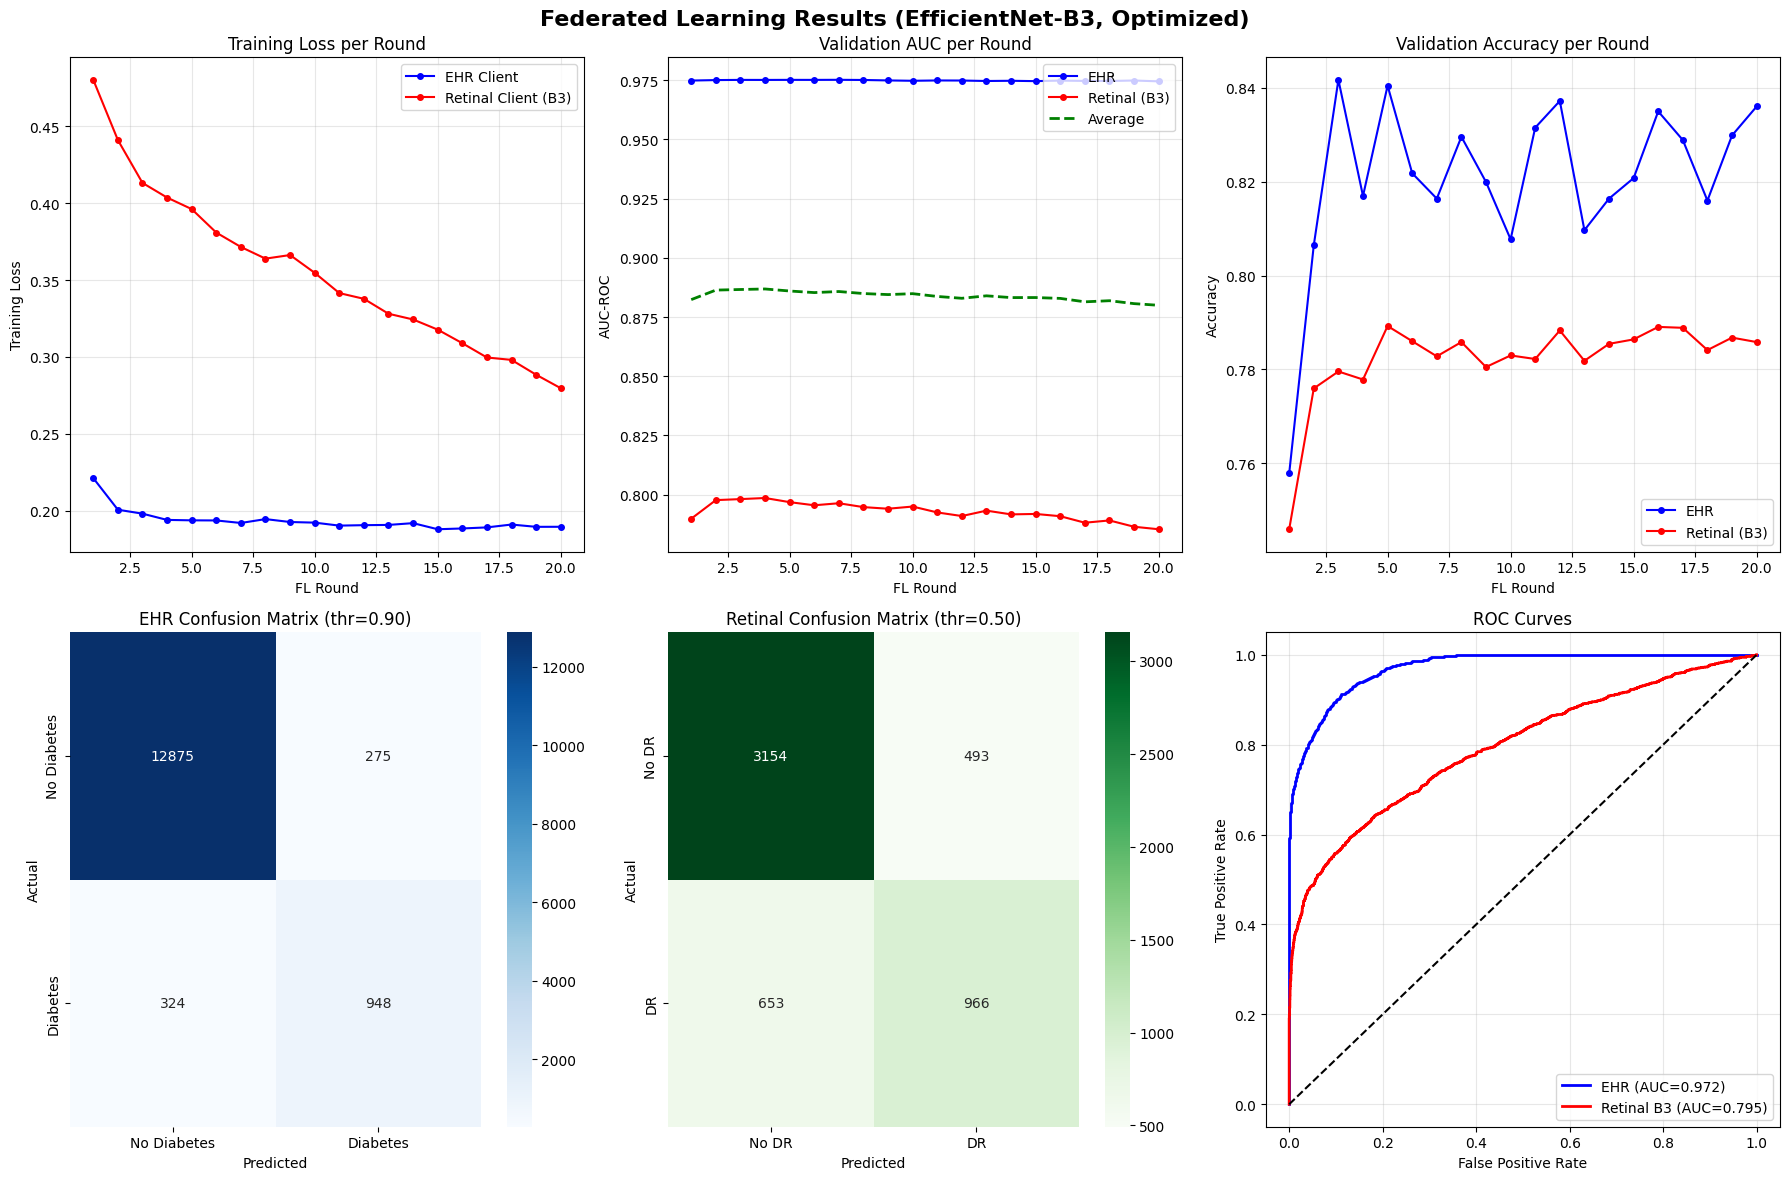


✓ Saved: /content/drive/MyDrive/MULTIMODAL/models/global_fl_b3_experiment/fl_results_b3.png


In [32]:
# ============================================================
# CELL 14: VISUALIZATIONS
# ============================================================
print("\n" + "=" * 70)
print("STEP 11: VISUALIZATIONS")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Federated Learning Results (EfficientNet-B3, Optimized)', fontsize=16, fontweight='bold')

# ─── Plot 1: Training Loss per Round ───
ax = axes[0, 0]
ax.plot(fl_history['round'], fl_history['ehr_train_loss'], 'b-o', label='EHR Client', markersize=4)
ax.plot(fl_history['round'], fl_history['ret_train_loss'], 'r-o', label='Retinal Client (B3)', markersize=4)
ax.set_xlabel('FL Round')
ax.set_ylabel('Training Loss')
ax.set_title('Training Loss per Round')
ax.legend()
ax.grid(alpha=0.3)

# ─── Plot 2: Validation AUC per Round ───
ax = axes[0, 1]
ax.plot(fl_history['round'], fl_history['ehr_val_auc'], 'b-o', label='EHR', markersize=4)
ax.plot(fl_history['round'], fl_history['ret_val_auc'], 'r-o', label='Retinal (B3)', markersize=4)
avg_auc_list = [(e + r) / 2 for e, r in zip(fl_history['ehr_val_auc'], fl_history['ret_val_auc'])]
ax.plot(fl_history['round'], avg_auc_list, 'g--', label='Average', linewidth=2)
ax.set_xlabel('FL Round')
ax.set_ylabel('AUC-ROC')
ax.set_title('Validation AUC per Round')
ax.legend()
ax.grid(alpha=0.3)

# ─── Plot 3: Validation Accuracy per Round ───
ax = axes[0, 2]
ax.plot(fl_history['round'], fl_history['ehr_val_acc'], 'b-o', label='EHR', markersize=4)
ax.plot(fl_history['round'], fl_history['ret_val_acc'], 'r-o', label='Retinal (B3)', markersize=4)
ax.set_xlabel('FL Round')
ax.set_ylabel('Accuracy')
ax.set_title('Validation Accuracy per Round')
ax.legend()
ax.grid(alpha=0.3)

# ─── Plot 4: EHR Confusion Matrix ───
ax = axes[1, 0]
cm_ehr = confusion_matrix(ehr_test_metrics['labels'], ehr_preds_optimal)
sns.heatmap(cm_ehr, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
ax.set_title(f'EHR Confusion Matrix (thr={ehr_best_thr:.2f})')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

# ─── Plot 5: Retinal Confusion Matrix ───
ax = axes[1, 1]
cm_ret = confusion_matrix(ret_test_metrics['labels'], ret_preds_optimal)
sns.heatmap(cm_ret, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['No DR', 'DR'],
            yticklabels=['No DR', 'DR'])
ax.set_title(f'Retinal Confusion Matrix (thr={ret_best_thr:.2f})')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

# ─── Plot 6: ROC Curves ───
ax = axes[1, 2]

fpr_ehr, tpr_ehr, _ = roc_curve(ehr_test_metrics['labels'], ehr_test_metrics['probs'])
ax.plot(fpr_ehr, tpr_ehr, 'b-', linewidth=2, label=f'EHR (AUC={ehr_test_metrics["auc"]:.3f})')

fpr_ret, tpr_ret, _ = roc_curve(ret_test_metrics['labels'], ret_test_metrics['probs'])
ax.plot(fpr_ret, tpr_ret, 'r-', linewidth=2, label=f'Retinal B3 (AUC={ret_test_metrics["auc"]:.3f})')

ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.SAVE_DIR, 'fl_results_b3.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: {config.SAVE_DIR}/fl_results_b3.png")

# **15. Save Global Model**

In [33]:
# ============================================================
# CELL 15: SAVE GLOBAL MODEL
# ============================================================
print("\n" + "=" * 70)
print("STEP 12: SAVING GLOBAL MODEL")
print("=" * 70)

# Ensure best classifier is in global_model, then save full model state
global_model.classifier.load_state_dict(best_classifier_state)
best_global_state = copy.deepcopy(global_model.state_dict())

save_path = os.path.join(config.SAVE_DIR, config.GLOBAL_MODEL_NAME)

checkpoint = {
    'model_state_dict': best_global_state,
    'ehr_dim': ehr_dim,
    'img_dim': img_dim,
    'fl_config': {
        'num_rounds': config.NUM_ROUNDS,
        'local_epochs_ehr': config.LOCAL_EPOCHS_EHR,
        'local_epochs_retinal': config.LOCAL_EPOCHS_RETINAL,
        'lr_ehr': config.LR_EHR,
        'lr_retinal': config.LR_RETINAL,
        'freeze_encoders': config.FREEZE_ENCODERS,
        'image_size': config.IMAGE_SIZE,
        'batch_size_retinal': config.BATCH_SIZE_RETINAL,
        'feat_batch_size': config.FEAT_BATCH_SIZE,
        'optimized': True
    },
    'fl_history': fl_history,
    'test_results': {
        'ehr': {
            'auc': ehr_test_metrics['auc'],
            'accuracy': ehr_test_metrics['accuracy'],
            'f1': ehr_test_metrics['f1'],
            'optimal_threshold': ehr_best_thr
        },
        'retinal': {
            'auc': ret_test_metrics['auc'],
            'accuracy': ret_test_metrics['accuracy'],
            'f1': ret_test_metrics['f1'],
            'optimal_threshold': ret_best_thr
        }
    },
    'timing': {
        'precomputation_seconds': t_precomp,
        'fl_training_seconds': t_fl_total,
        'total_seconds': t_precomp + t_fl_total
    },
    'ehr_model_config': ehr_checkpoint.get('config', {}),
    'retinal_model_config': ret_checkpoint.get('config', {})
}

torch.save(checkpoint, save_path)
print(f"✓ Global model saved to: {save_path}")


STEP 12: SAVING GLOBAL MODEL
✓ Global model saved to: /content/drive/MyDrive/MULTIMODAL/models/global_fl_b3_experiment/global_multimodal_fl_b3.pth


# **16. Final Summary**

In [34]:
# ============================================================
# CELL 16: FINAL SUMMARY
# ============================================================
print("\n" + "=" * 70)
print("FEDERATED LEARNING SUMMARY (EfficientNet-B3, Optimized)")
print("=" * 70)

print(f"""
Configuration:
────────────────────────────────────────
  FL Rounds:           {config.NUM_ROUNDS}
  Local Epochs:        EHR={config.LOCAL_EPOCHS_EHR}, Ret={config.LOCAL_EPOCHS_RETINAL}
  Freeze Encoders:     {config.FREEZE_ENCODERS}
  Aggregation:         FedAvg (weighted by dataset size)
  Feature batch size:  {config.FEAT_BATCH_SIZE}

Optimization:
────────────────────────────────────────
  ⚡ Pre-computed encoder features (one-time)
  ⚡ Classifier-only training & aggregation
  ⚡ A100: TF32 + cudnn.benchmark
  ⚡ BF16 autocast for pre-computation

Data:
────────────────────────────────────────
  EHR Train:     {len(ehr_train_df):,} samples
  EHR Test:      {len(ehr_test_df):,} samples
  Retinal Train: {len(ret_train_df):,} samples
  Retinal Test:  {len(ret_test_df):,} samples

Model Architecture:
────────────────────────────────────────
  EHR Encoder:      MLP → {ehr_dim} features
  Retinal Encoder:  EfficientNet-B3 → {img_dim} features
  Combined:         {ehr_dim + img_dim} features
  Classifier:       {ehr_dim + img_dim} → 256 → 64 → 1

Timing:
────────────────────────────────────────
  Pre-computation: {t_precomp:.1f}s ({t_precomp/60:.1f} min)
  FL Training:     {t_fl_total:.1f}s ({t_fl_total/60:.1f} min)
  Total:           {t_precomp + t_fl_total:.1f}s ({(t_precomp + t_fl_total)/60:.1f} min)

Test Results (Global FL Model with B3):
────────────────────────────────────────
  EHR Modality:
    AUC:       {ehr_test_metrics['auc']:.4f}
    Accuracy:  {accuracy_score(ehr_test_metrics['labels'], ehr_preds_optimal):.4f} (thr={ehr_best_thr:.2f})
    F1-Score:  {ehr_best_f1:.4f}

  Retinal Modality:
    AUC:       {ret_test_metrics['auc']:.4f}
    Accuracy:  {accuracy_score(ret_test_metrics['labels'], ret_preds_optimal):.4f} (thr={ret_best_thr:.2f})
    F1-Score:  {ret_best_f1:.4f}

  Average AUC: {(ehr_test_metrics['auc'] + ret_test_metrics['auc']) / 2:.4f}

Comparison with B2 FL Model:
────────────────────────────────────────
  B2 FL: EHR AUC=0.9714, Ret AUC=0.7675, Avg=0.8695
  B3 FL: EHR AUC={ehr_test_metrics['auc']:.4f}, Ret AUC={ret_test_metrics['auc']:.4f}, Avg={(ehr_test_metrics['auc'] + ret_test_metrics['auc']) / 2:.4f}

Files Saved:
────────────────────────────────────────
  Global Model: {config.SAVE_DIR}/{config.GLOBAL_MODEL_NAME}
  Plot:         {config.SAVE_DIR}/fl_results_b3.png

────────────────────────────────────────
✓ FEDERATED LEARNING COMPLETE
────────────────────────────────────────
""")


FEDERATED LEARNING SUMMARY (EfficientNet-B3, Optimized)

Configuration:
────────────────────────────────────────
  FL Rounds:           20
  Local Epochs:        EHR=1, Ret=1
  Freeze Encoders:     True
  Aggregation:         FedAvg (weighted by dataset size)
  Feature batch size:  256

Optimization:
────────────────────────────────────────
  ⚡ Pre-computed encoder features (one-time)
  ⚡ Classifier-only training & aggregation
  ⚡ A100: TF32 + cudnn.benchmark
  ⚡ BF16 autocast for pre-computation

Data:
────────────────────────────────────────
  EHR Train:     11,876 samples
  EHR Test:      14,422 samples
  Retinal Train: 15,128 samples
  Retinal Test:  5,266 samples

Model Architecture:
────────────────────────────────────────
  EHR Encoder:      MLP → 32 features
  Retinal Encoder:  EfficientNet-B3 → 1536 features
  Combined:         1568 features
  Classifier:       1568 → 256 → 64 → 1

Timing:
────────────────────────────────────────
  Pre-computation: 1972.3s (32.9 min)
  FL Tra

# **17. Helper Code for Loading Global Model**

In [35]:


# ============================================================
# CELL 17: HELPER CODE FOR LOADING GLOBAL MODEL
# ============================================================
print("\n" + "=" * 70)
print("HELPER CODE FOR LOADING GLOBAL MODEL (B3)")
print("=" * 70)

helper_code = '''
# ============================================================
# Copy this code to load the global FL model (B3) in other notebooks
# ============================================================
import torch
import torch.nn as nn
from torchvision import models

# Define model classes (same as training)
class EHRClassifier(nn.Module):
    def __init__(self, n_features, hidden_dims=[128, 64, 32], dropout_rate=0.3):
        super().__init__()
        layers = []
        in_dim = n_features
        for i, out_dim in enumerate(hidden_dims):
            layers.extend([
                nn.Linear(in_dim, out_dim),
                nn.BatchNorm1d(out_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate if i < len(hidden_dims) - 1 else dropout_rate * 0.5)
            ])
            in_dim = out_dim
        self.feature_extractor = nn.Sequential(*layers)
        self.feature_dim = hidden_dims[-1]

class BinaryDRClassifier(nn.Module):
    def __init__(self, model_name='efficientnet_b3', dropout=0.3):
        super().__init__()
        self.backbone = models.efficientnet_b3(weights=None)
        n = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        self.feature_dim = n  # 1536 for B3
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(n, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, 1)
        )

class GlobalMultimodalModel(nn.Module):
    def __init__(self, ehr_encoder, ret_encoder, ehr_dim, img_dim):
        super().__init__()
        self.ehr_encoder = ehr_encoder
        self.ret_encoder = ret_encoder
        self.ehr_dim = ehr_dim
        self.img_dim = img_dim
        self.classifier = nn.Sequential(
            nn.Linear(ehr_dim + img_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 1)
        )

    def forward_ehr(self, x_ehr):
        ehr_feats = self.ehr_encoder(x_ehr)
        img_zero = x_ehr.new_zeros(x_ehr.size(0), self.img_dim)
        fused = torch.cat([ehr_feats, img_zero], dim=1)
        return self.classifier(fused)

    def forward_retinal(self, x_img):
        img_feats = self.ret_encoder(x_img)
        ehr_zero = x_img.new_zeros(x_img.size(0), self.ehr_dim)
        fused = torch.cat([ehr_zero, img_feats], dim=1)
        return self.classifier(fused)

# Load global model (B3 version)
def load_global_model(checkpoint_path, ehr_model_path, ret_model_path, device='cpu'):
    global_ckpt = torch.load(checkpoint_path, map_location=device)
    ehr_ckpt = torch.load(ehr_model_path, map_location=device)
    ret_ckpt = torch.load(ret_model_path, map_location=device)

    ehr_model = EHRClassifier(
        n_features=ehr_ckpt['n_features'],
        hidden_dims=ehr_ckpt['hidden_dims']
    )
    ehr_model.load_state_dict(ehr_ckpt['model_state_dict'])

    ret_model = BinaryDRClassifier(model_name='efficientnet_b3')
    ret_model.load_state_dict(ret_ckpt['model_state_dict'])

    model = GlobalMultimodalModel(
        ehr_encoder=ehr_model.feature_extractor,
        ret_encoder=ret_model.backbone,
        ehr_dim=global_ckpt['ehr_dim'],
        img_dim=global_ckpt['img_dim']
    )
    model.load_state_dict(global_ckpt['model_state_dict'])
    model.to(device)
    model.eval()
    return model, global_ckpt

# Usage:
# model, ckpt = load_global_model(
#     'global_multimodal_fl_b3.pth',
#     'mlp_ehr_binary_diabetes.pth',
#     'efficientnet_b3_binary_dr_twostage.pth'
# )
#
# # EHR inference:
# logits = model.forward_ehr(ehr_data)
# probs = torch.sigmoid(logits)
#
# # Retinal inference (300x300 images):
# logits = model.forward_retinal(retinal_images)
# probs = torch.sigmoid(logits)
'''

print(helper_code)

print("\n" + "=" * 70)
print("✓ NOTEBOOK COMPLETE")
print("=" * 70)


HELPER CODE FOR LOADING GLOBAL MODEL (B3)

# ============================================================
# Copy this code to load the global FL model (B3) in other notebooks
# ============================================================
import torch
import torch.nn as nn
from torchvision import models

# Define model classes (same as training)
class EHRClassifier(nn.Module):
    def __init__(self, n_features, hidden_dims=[128, 64, 32], dropout_rate=0.3):
        super().__init__()
        layers = []
        in_dim = n_features
        for i, out_dim in enumerate(hidden_dims):
            layers.extend([
                nn.Linear(in_dim, out_dim),
                nn.BatchNorm1d(out_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate if i < len(hidden_dims) - 1 else dropout_rate * 0.5)
            ])
            in_dim = out_dim
        self.feature_extractor = nn.Sequential(*layers)
        self.feature_dim = hidden_dims[-1]

class BinaryDRClassifier(nn.Module):
